<h1>Conception d'un Amplificateur à configuration non inverseuse et d'un filtre passe bas</h1>

<h2>Amplificateur</h2>

<p>Nous réalisons un circuit d'amplification  d'un signal électrique (la tension), afin d'augmenter son amplitude. Le circuit est à configuration non inverseuse afin de conserver le signe ou la polarité de la tension.</p>
<p>Le circuit est constitué d'un amplificateur opérationnel et deux résistances comme sur l'image ci-dessous</p>
<img src="ampli.png">
<p>Nous considérons que l'ampli-op utilisé est linéaire dans l'intervalle de fonctionnement $\frac{L_{-}}{A_v}<=V_{in}<=\frac{L_{+}}{A_v}$ avec $A_v$ le gain en tension, $L_-$ et $L_+$ les niveaux de saturation : les tensions d'alimentation de l'ampli-op.</p>
<p>Nous supposons aussi que l'ampli-op est idéal i.e. sa résistance d'entrée est infinie, sa résistance de sortie est nulle, son gain en boucle ouverte est infini, sa rejection en mode commun ainsi que sa bande passante sont aussi infinies.</p>
<p>Avec un peu d'analyse des circuits (méthode nodale), on montre que le gain est donné part : $\frac{V_{out}}{V_{in}} = 1 + \frac{R_f}{R_1}$</p>

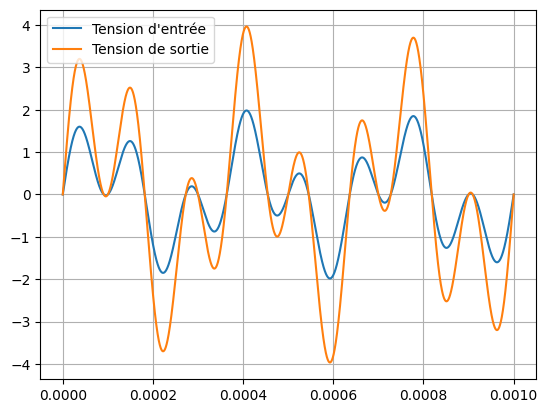

In [52]:
# Importons les modules matplotlib et numpy pour la visualisation des graphiques
# et les calculs

import matplotlib.pyplot as plt
import numpy as np

def ampli_non_inverseuse(v_in:np.ndarray, r1:float, rf:float) -> np.ndarray:
    """Cette fonction prend en argument un tableau array (qui
    représente le signal d'entrée à des instants donnés), les
    résistances r1 et rf(en contre-réaction).
    """
    gain = 1 + rf/r1
    return gain*v_in

# Exemple
R1, Rf = 1, 1
ECHANTILLONS = 9000
t_final = 0.001
t = np.linspace(0, t_final, ECHANTILLONS)
signal_in = np.sin(2*np.pi*3000*t) + np.sin(2*np.pi*8000*t)
signal_sortie1 = ampli_non_inverseuse(signal_in, R1, Rf)

plt.plot(t, signal_in, label="Tension d'entrée")
plt.plot(t, signal_sortie1, label="Tension de sortie")
plt.legend()
plt.grid()

<h2>Filtre passe-bas</h2>

<p>Afin de supprimer le bruit ou les perturbations présentent dans le signal de sortie de l'amplificateur, nous devons réaliser un filtre. Etant donné que nous nous intéressons aux basses fréquences, nous parlerons d'un filtre passe-bas qui par définition bloque les hautes fréquences.</p>
<p>Un filtre est un système capable de modifier le contenu fréquentiel d'un signal, soit en attenuant les basses fréquences(filtre passe-haut), soit en attenuant les hautes fréquences(filtre passe-bas) soit en attenuant une tranche de fréquences données(filtres passe-bande et stop-bande).</p>
<table>
    <caption>Types de filtres(Introductory circuit analysis, 14e edition, page 924)</caption>
    <tr>
        <td><img src="filtre_passe_bas.png"></td>
        <td><img src="filtre_passe_haut.png"></td>
    </tr>
    <tr>
        <td><img src="filtre_passe_bande.png"></td>
        <td><img src="filtre_stop_bande.png"></td>
    </tr>
</table>

<p>En pratique, il n'est pas possible de réaliser un filtre passe-bas idéal i.e. qui supprime totalement les contributions des fréquences supérieures à une certaine valeur(fréquence de coupure) ; c'est dû à la non causalité de ce système. Nous recourons à des systèmes qui, au lieu de supprimer, attenuent les hautes fréquences : le filtre Butterworth, le filtre Bessel et le filtre de Chebychev en sont des exemples les plus utilisés.</p>
<p>Le filtre Butterworth garantit un gain quasi-constant dans la bande-passante, le filtre de Bessel favorise la linéarité de la réponse en phase dans la bande passante et le filtre de Chebyshev assure une parfaite atténuation en déhors de la bande passante. Nous ne parlerons que des filtres de Butterworth et de Chebychev dont les réponses typiques sont montrées sur l'image suivante.</p>

<figure>
    <img src="butterworth_cheby.png">
    <figcaption>Filtre de Butterworth(a) et de Chebychev(b). Introductory circuit analysis, 14e edition, page 940</figcaption>
</figure>
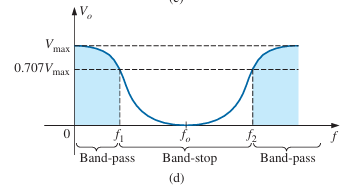
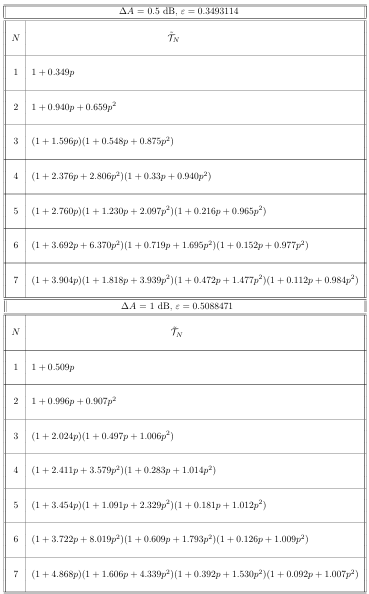

<h3>Filtre de Butterworth</h3>
<p>La réponse fréquentielle d'un filtre de Butterworth d'ordre n est de la forme : $H(j\omega) = \frac{1}{1+j(\frac{\omega}{\omega_c})^n}$, avec $\omega_c$ la pulsation de coupure. L'ordre $n$ du filtre est déterminé en fonction de l'atténuation minimale dans la bande rejetée(notée $b$).</p>
<p>$G(j\omega_s) = 20.\log{|H(j\omega_s)|} <= b$. Ainsi, $n >= \frac{\log{(10^{-b/10}}-1)}{2.\log{(\omega_s/\omega_c)}}$, avec $\omega_s$ la fréquence angulaire(pulsation) d'atténuation.</p>
<p>Nous parlerons des filtres d'ordre supérieur à deux. La réalisation de tels filtres se fait par la mise en cascade des filtres d'ordre 1 ou 2, que ce soit pour un filtre de Butterworth ou tout autre type de filtre réel. Définissons quelques concepts déjà évoqués avant de passer à l'étude des cellules d'ordre 2 de Sallen et Key nécessaires pour réaliser un filtre d'ordre supérieur à deux.</p>
<p>On appelle fréquence de coupure, la valeur de la fréquence pour laquelle le gain du filtre passe à $-3~dB$. Pour un filtre idéal, il s'agit de la fréquence de passage de la bande passante à la bande rejetée.</p>
<p>On appelle bande passante(à l'opposé de la bande rejetée), la bande des fréquences pour lesquelles le gain est quasiment constant.</p>
<p>Nous distinguons deux types de filtres d'après les composants qui les constituent : les filtres passifs et les filtres actifs constitués respectivement des éléments passifs et d'au moins un élément actif. Une cellule de Sallen et Key est une implémentation d'un filtre actif d'ordre deux. Le schéma qui suit représente ce filtre(version passe-bas), il est formé d'un ampli-op, d'une paire de résistances(conventionnellement identiques) et d'une paire de condensateurs.</p>

<figure>
    <img src="sallen_key.png">
    <figcaption>Cellule de Sallen et Key(Electronique analogique, Freddy Mudry, page 176)</figcaption>
</figure>

<p>Sa fonction de transfert est donnée par : $F(s) = \frac{1}{1 + 2C_2Rs + C_1C_2R^2s^2}$</p>
<p>Comme cellule d'ordre un, nous considérons un filtre passe-bas RC i.e. constitué d'une résistance et d'un condensateur comme sur l'image ci-dessous. Sa fonction, très facile à calculer, est donnée par : $F(s) = \frac{1}{1 + \tau.s}$ avec $\tau = R.C$ la constante du temps.</p>
<img src="RC_filter_bas.png">
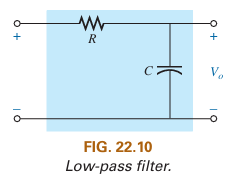

<h3>Filtre de Chebyshev direct</h3>
<p>Le filtre de Chebychev(direct ou inverse) permet d'obtenir une pente de coupure plus raide que celui d'un filtre Butterworth. Il autorise en contre partie des ondulations contrôlées, soit dans la bande passante(Chebychev direct, type I), soit dans la bande atténuée(Chebychev inverse, type II). Les modules de ces deux types de filtre de Chebychev sont respectivement : $|H(j\omega)|^2 = \frac{1}{1 + \epsilon^2T_n^2(\omega/\omega_c)}$ et $|H(j\omega)|^2 = (1 + \frac{1}{\epsilon^2T_n^2(\omega_c/\omega)})^{-1}$, avec $T_n(x)$ le polynome de Chebychev d'ordre n. Dans le cas d'un filtre de Chebychev, $\omega_c$ désigne la fréquence qui marque la fin de la bande passante et non la fréquence à laquelle le gain chute à -3dB ; $\epsilon$ est un coefficient qui contrôle l'amplitude de l'ondulation dans la bande passante.</p>
<p>La fonction de transfert d'un filtrede Chebychev inverse comporte à la fois des zéros et des pôles, ce qui rend complexe la conception et réalisation d'un filtre de type II de Chebychev. Dans la suite, pour des raisons de simplicité, nous ne concidérons que le filtre de type I dont le gain dans la bande passante oscille entre $\frac{1}{\sqrt{1 + \epsilon^2}}$ et $1$ suite aux propriétés de la fonction $T_n(x)$</p>
<h4>Polynôme de Chebyshev</h4>
<p>Le polynome $T_n(x)$ dit de Chebychev est tel que pour tout réel $x$ compris entre $-1$ et $1$, $T_n(x)$ est aussi compris entre $-1$ et $1$ ; et pour tout autre réel $x$, $T_n(x)$ est strictement supérieur à $1$. Dans la bande passante, $\frac{\omega}{\omega_c}$ est compris entre $-1$ et $1$, d'où $0<=T_n^2(\frac{\omega}{\omega_c})<=1$. Ainsi $\frac{1}{\sqrt{1+\epsilon^2}}<=|H(j\omega)|<=1$</p>
<p>Par définition, pour $n=0,1,2,...k$ et x entre $-1$ et $1$, $T_n(x)=\cos{(n*\phi)}$ où $x=\cos{(\phi)}$.</p>
<p>Comme $\cos{[(n+1)\phi]}+\cos{[(n-1)\phi]} = 2\cos{(\phi)}\cos{(n\phi)}$, alors $T_0(x) = 1$, $T_1(x) = x$, $T_2(x) = 2xT_1(x)-T_0(x)$ et $T_{n+1}(x) = 2xT_n(x)-T_{n-1}(x)$.</p>
<p></p>
<p>Plus $\epsilon$ est grand, plus l'ondulation est forte, et plus la transition sera rapide. Le cahier de charge d'un tel filtre contient : la fréquence d'ondulation, la valeur maximale des ondulations dans la bande passante($A_{max}$) en dB, la valeur minimale de l'atténuation($A_{min}$ à une fréquence $\omega_a$. La pente de transition de la réponse fréquentielle d'un filtre de Chebychev devient de plus en plus raide en mesure que l'ordre du filtre augmente ; aussi la conception du système devient-elle de plus en plus complexe et coûteuse. On montre que :</p>
<ul>
    <li>$\epsilon = \sqrt{10^{A_{max}/10}-1}$</li>
    <li>à $\omega=\omega_a$, $T_n(\frac{\omega_a}{\omega_c})>=\frac{\sqrt{10^{A_{min}/10}-1}}{\epsilon}$</li>
    <li>$n>=\frac{\operatorname{arcosh}{(\sqrt{\frac{10^{A_{min}/10}-1}{10^{A_{max}/10}-1}})}}{\operatorname{arcosh}{(\frac{\omega_a}{\omega_c})}}$</li>
</ul>
<p>Pour déterminer la fonction de transfert qui nous permettra de passer à la réalisation, nous utilisons des tables de polynomes normalisés pour des valeurs standardes de $A_{max}$. Cette fonction de transfert normalisée est un produit des cellules du premier et du deuxième ordre. Nous passons facilement des conditions normales à nos conditions en remplaçant $s$ par $\frac{s}{\omega_c}$ dans la fonction de transfert ; ensuite il ne restera qu'à identifier les cellules par leurs modèles physiques i.e. dimensionner les composants. Notons que nous pouvons aussi passer par des calculs directs pour obtenir cette fonction de transfert si nous manquons de table. En plus chaque table proposé à son mode d'emploi et exige de considérer la fréquence de référence dans ces conditions suivant l'approximation choisie ; celle que nous utilisons est donnée dans le chapitre 10 du d'électrocinétique élémentaire de Christian Carimalo.</p>
<img src="table_norm.png">
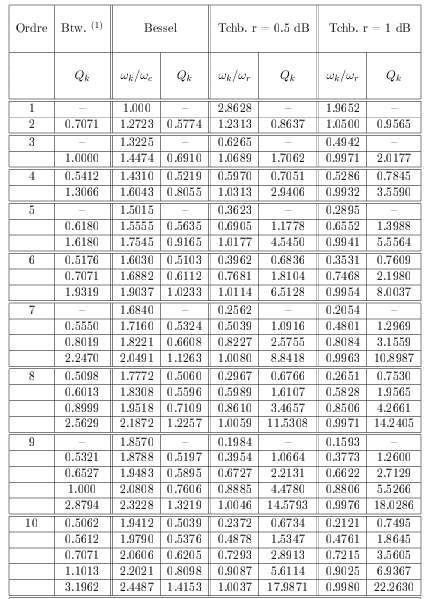
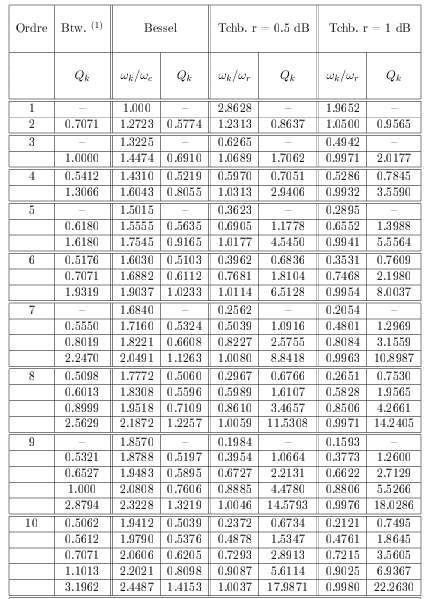

In [53]:
# Calcul préliminaire d'un filtre de Chebyshev
f_c = 4000  # fréquence de coupure [Hz]
A_max = 0.5 # [dB]
A_min, f_a = 40, 8000 # [dB], [Hz]

eps = np.sqrt(10**(A_max / 10) - 1)
n = np.arccosh(np.sqrt((10**(A_min / 10) - 1)/(10**(A_max / 10) - 1))) / np.arccosh(f_a / f_c) # L'ordre du filtre de Chebyshev
n = np.round(n)
print(f"eps = {np.round(eps, 4)}")
print(f"L'ordre du filtre est de : {n}")
# Détermination des cellules
if not n%2:
    print(f"Il nous faut {n//2} cellules d'ordre 2(de Sallen-Key)")
else:
    print(f"Il nous faut une cellule d'ordre 1 et {n//2} cellules d'ordre 2")

eps = 0.3493
L'ordre du filtre est de : 5.0
Il nous faut une cellule d'ordre 1 et 2.0 cellules d'ordre 2


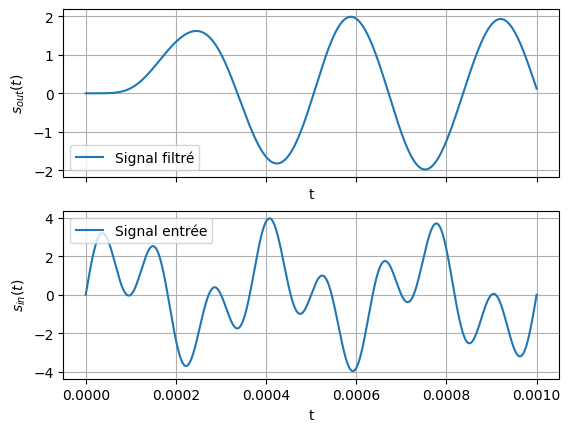

In [58]:
# Le module scipy nous permet de simuler un filtre de Chebyshev direct
# Pour plus de détails voir la documentation officielle
from scipy.signal import cheby1, sosfilt

fs = ECHANTILLONS / t_final # fréquence d'échantillonnage
filtre_cheby = cheby1(n, rp=A_max, Wn=f_c, btype="lowpass", analog=False, output="sos", fs=fs)
# rp : A_max
# Wn : fc en Hz si fs est donnée
# btype : type de filtre "lowpass", "highpass", "bandstop", "bandpass"
# analog : False pour filtre numérique
# output : "sos" recommandé
# cheby1 retourne les coefficient du numérateur et dénominateur de la fonction de transfert
signal_sortie2 = sosfilt(filtre_cheby, x=signal_sortie1)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(t, signal_sortie2, label="Signal filtré")
ax1.grid()
ax1.legend()
ax1.set_xlabel("t")
ax1.set_ylabel(r"$s_{out}(t)$")

ax2.plot(t, signal_sortie1, label="Signal entrée")
ax2.grid()
ax2.legend()
ax2.set_xlabel("t")
ax2.set_ylabel(r"$s_{in}(t)$")
ax2.legend()


<h2>Dimensionnement des composants</h2>
<img src="dimensionnement.jpg">